# 07 — Moving-median baseline removal and unfiltered airwave measurements

This notebook replaces the experimental local-linear-baseline workflow.

Visual inspection showed that a line fitted to short pre-event and post-event
segments could acquire an unrealistically steep slope because it depended too
strongly on a small number of samples. In contrast, the long-window moving
median followed the slowly varying pressure baseline well without imposing a
sharp linear trend.

The adopted workflow therefore uses:

1. the response-corrected, **unfiltered** pressure waveform;
2. a long-window moving median as the local baseline;
3. pressure measured relative to that baseline;
4. a positive compression peak followed by a negative rarefaction peak;
5. a required compression-to-rarefaction lag of at least 0.01 s;
6. a provisional one-cycle event interval inferred from the peak separation.

No Butterworth filter is applied in this notebook.

## Processing history and experiments

The event catalogue and pressure-processing strategy evolved through the
following steps.

1. **Manual candidate picking in Antelope `dbpick`.** Candidate airwave arrivals
   were picked manually on the BCHH channels. These original pick times are the
   most important legacy observations and were exported from MATLAB/GISMO with
   millisecond precision.
2. **Legacy event catalogues.** Earlier MATLAB workflows produced catalogues of
   153 and 157 events. Their precise start/end times were recovered, but neither
   catalogue was treated automatically as ground truth.
3. **Differential-travel-time association.** HD1, HD2, and HD3 picks were reduced
   to a common reference time using surveyed source-to-sensor distances and a
   wind-assisted acoustic speed. This removed the normal 0.08–0.09 s array
   traversal delay and allowed short-window multi-channel association.
4. **Shifted waveform stacks.** Differentially shifted mean and median stacks
   were generated to assess coherence and improve visibility of weak events.
5. **Butterworth high-pass experiment.** A filter bank from 0.5 to 20 Hz was
   tested. Some filters improved SNR for some events but degraded others and
   altered the apparent compression-rarefaction shape. Filtering is therefore
   not used for physical pressure measurements.
6. **Local linear-baseline experiment.** Baselines fitted to short exterior
   windows often developed steep, implausible trends because too few samples
   controlled the fit.
7. **Moving-median baseline.** Visual review showed that the long-window moving
   median followed the slowly varying baseline more plausibly. This notebook
   adopts that baseline directly for pressure measurements.

A later detection-only workflow may still use a gently filtered waveform as a
guide for very weak arrivals, but reported pressure amplitudes should come from
the unfiltered, response-corrected data after moving-median baseline removal.

07_optimize_local_infrasound_baseline_moving_median_v2.ipynb
Useful, but numbered in the wrong place.
It establishes the adopted moving-median baseline treatment, tests window lengths, and explicitly avoids applying a high-pass filter to pressure measurements. This processing decision affects the candidate-event and amplitude notebooks, so it should precede them.
Rename to:
06_validate_infrasound_baseline_correction.ipynb
I would avoid the word optimize unless the notebook truly performs a formal optimization. It is better described as validation and sensitivity testing.
Once the 1 s median window is accepted, move the reusable implementation into a Python module and leave the notebook as evidence supporting that choice.
Verdict: keep, rename, and move earlier.


## 1. Imports and project paths

In [1]:
from pathlib import Path
from collections.abc import Mapping
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import median_filter
from obspy import Stream, Trace, UTCDateTime, read

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from project_config import ensure_output_dirs

PATHS = ensure_output_dirs(PROJECT_ROOT)
DERIVED_DIR = PATHS["derived"]

REDUCED_REVIEW_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "event_waveform_review_reduced_time"
)
FILTER_OPTIMIZATION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "highpass_filter_optimization"
)

EVENT_FILE = (
    REDUCED_REVIEW_DIR
    / "derived"
    / "reconstructed_reduced_time_events_with_legacy_matches.csv"
)
PICK_ASSIGNMENT_FILE = (
    REDUCED_REVIEW_DIR
    / "derived"
    / "reduced_time_pick_assignments.csv"
)
STACK_METRICS_FILE = REDUCED_REVIEW_DIR / "stack_metrics.csv"
SELECTED_FILTER_EVENTS_FILE = (
    FILTER_OPTIMIZATION_DIR
    / "derived"
    / "selected_filter_test_events.csv"
)
STREAM_FILE = DERIVED_DIR / "bchh_corrected_analysis_window.pkl"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "moving_median_baseline"
EVENT_PLOT_DIR = OUTPUT_DIR / "event_diagnostics"
SUMMARY_PLOT_DIR = OUTPUT_DIR / "summary_figures"
DERIVED_OUTPUT_DIR = OUTPUT_DIR / "derived"

for directory in [
    OUTPUT_DIR,
    EVENT_PLOT_DIR,
    SUMMARY_PLOT_DIR,
    DERIVED_OUTPUT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

BASELINE_REMOVED_PICKLE = (
    DERIVED_DIR
    / "bchh_corrected_moving_median_baseline_removed.pkl"
)
BASELINE_REMOVED_MSEED = (
    DERIVED_DIR
    / "bchh_corrected_moving_median_baseline_removed.mseed"
)

plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "figure.dpi": 120,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Input stream: {STREAM_FILE}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper
Input stream: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/derived/bchh_corrected_analysis_window.pkl
Output directory: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/moving_median_baseline


## 2. Configuration

In [2]:
INFRASOUND_CHANNELS = ("HD1", "HD2", "HD3")
SEISMIC_CHANNELS = ("HHZ", "HHN", "HHE")

BCHH_INFRASOUND_DISTANCES_M = {
    "HD1": 1442.2,
    "HD2": 1410.2,
    "HD3": 1414.8,
}
REFERENCE_CHANNEL = "HD2"
WIND_CORRECTED_ACOUSTIC_SPEED_MPS = 351.0

# Adopted whole-stream moving-median baseline length.
# This is much longer than a typical ~0.05–0.20 s impulsive airwave.
MOVING_MEDIAN_WINDOW_S = 1.0

# Optional windows retained for sensitivity plots on selected events.
MOVING_MEDIAN_TEST_WINDOWS_S = (0.125, 0.25, 0.50, 1.00, 2.00)

MAX_SELECTED_EVENTS = 24

# Event extraction relative to reconstructed reduced time.
EXTRACT_PRE_S = 0.65
EXTRACT_POST_S = 0.75

# Search for the compression-rarefaction pair near the associated event.
SIGNAL_SEARCH_WINDOW_S = (-0.04, 0.25)

# Enforce positive compression first and negative rarefaction later.
MINIMUM_POSITIVE_NEGATIVE_LAG_S = 0.010
MAXIMUM_POSITIVE_NEGATIVE_LAG_S = 0.180

# For an approximately sinusoidal one-cycle signal, A-to-B is half a period.
BOUNDARY_EXTENSION_FRACTION = 0.50

# Optional return-to-noise boundary refinement.
REFINE_BOUNDARIES_TO_NOISE = True
NOISE_WINDOW_S = (-0.40, -0.10)
BOUNDARY_NOISE_MULTIPLIER = 2.0
BOUNDARY_CONSECUTIVE_SAMPLES = 3
MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S = 0.12

WRITE_EVENT_DIAGNOSTIC_PNGS = True

### Why 1.0 s is currently the default

The 1.0 s moving-median window is a **provisional conservative choice**, not a
result already established as optimal.

Most impulsive airwaves considered here occupy roughly 0.05–0.20 s. A baseline
window should be several times longer than the signal so that the median is
controlled mainly by background samples rather than by the pulse itself. A
1.0 s window is therefore approximately 5–20 times longer than a typical event.

The notebook tests 0.25, 0.5, 1.0, and 2.0 s windows. The final value should be
chosen from:

- visual baseline quality;
- stability of positive, negative, and peak-to-peak pressure;
- preservation of event duration and impulse;
- minimal absorption of the signal into the estimated baseline;
- absence of excessive smoothing across genuine slow baseline changes.

### Is the moving median causal or zero phase?

The implementation uses a **centered, symmetric moving-median window**:

```python
median_filter(values, size=window_samples, mode="nearest")
```

Each baseline value uses samples from both before and after that time. It is
therefore **noncausal** and suitable for retrospective analysis.

A moving median is nonlinear, so it does not have a conventional frequency
response or phase response and should not technically be called a zero-phase
filter. However, because the window is centered rather than one-sided, it does
not introduce the systematic time delay associated with a causal running
filter. Event timing remains aligned with the original waveform.

## 3. Load the response-corrected Stream and event products

In [3]:
for required_file in [
    STREAM_FILE,
    EVENT_FILE,
    PICK_ASSIGNMENT_FILE,
    STACK_METRICS_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required input not found: {required_file}"
        )

st_corr = read(str(STREAM_FILE), format="PICKLE")
events = pd.read_csv(EVENT_FILE)
pick_assignments = pd.read_csv(PICK_ASSIGNMENT_FILE)
stack_metrics = pd.read_csv(STACK_METRICS_FILE)

events = events.merge(
    stack_metrics,
    on="reconstructed_event_number",
    how="left",
    validate="one_to_one",
)

events["reduced_event_time"] = pd.to_datetime(
    events["reduced_event_epoch_s"],
    unit="s",
    utc=True,
)

if SELECTED_FILTER_EVENTS_FILE.exists():
    previously_selected_events = pd.read_csv(
        SELECTED_FILTER_EVENTS_FILE
    )
else:
    previously_selected_events = pd.DataFrame()

print(st_corr)
print(f"Reconstructed events: {len(events)}")
print(f"Assigned picks: {len(pick_assignments)}")

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Reconstructed events: 154
Assigned picks: 384


## 4. Moving-median implementation

In [4]:
def odd_sample_count(
    duration_s: float,
    sampling_rate_hz: float,
) -> int:
    count = max(
        3,
        int(round(duration_s * sampling_rate_hz)),
    )
    if count % 2 == 0:
        count += 1
    return count


def moving_median_baseline(
    values: np.ndarray,
    *,
    sampling_rate_hz: float,
    window_s: float,
) -> np.ndarray:
    """
    Estimate a slowly varying baseline with a centered moving median.

    scipy.ndimage.median_filter is used because it is substantially faster
    than a pandas rolling median for the full 33-minute, 250-Hz stream.
    """
    values = np.asarray(values, dtype=float)
    window_samples = odd_sample_count(
        window_s,
        sampling_rate_hz,
    )

    return median_filter(
        values,
        size=window_samples,
        mode="nearest",
    )


def remove_moving_median_baseline(
    trace: Trace,
    *,
    window_s: float,
) -> tuple[Trace, np.ndarray]:
    corrected = trace.copy()
    baseline = moving_median_baseline(
        corrected.data,
        sampling_rate_hz=float(
            corrected.stats.sampling_rate
        ),
        window_s=window_s,
    )
    corrected.data = (
        corrected.data.astype(float) - baseline
    )
    corrected.stats.processing = list(
        getattr(corrected.stats, "processing", [])
    )
    corrected.stats.processing.append(
        "moving-median baseline removed: "
        f"window={window_s:g} s"
    )
    return corrected, baseline

## 5. Remove the moving-median baseline from the complete Stream

The three infrasound channels are baseline corrected. The three seismic channels
are copied unchanged so the result remains a complete six-channel Stream.

The original `st_corr` object is not modified.

In [5]:
st_corr_median_removed = Stream()
whole_stream_baselines = {}

for trace in st_corr:
    if trace.stats.channel in INFRASOUND_CHANNELS:
        corrected_trace, baseline = (
            remove_moving_median_baseline(
                trace,
                window_s=MOVING_MEDIAN_WINDOW_S,
            )
        )
        st_corr_median_removed += corrected_trace
        whole_stream_baselines[
            trace.id
        ] = baseline
    else:
        st_corr_median_removed += trace.copy()

st_corr_median_removed.sort()

print(st_corr_median_removed)

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples


## 6. Save the complete baseline-removed Stream

In [6]:
# ObsPy's PICKLE writer expects a writable file object in some versions.
with BASELINE_REMOVED_PICKLE.open("wb") as file_object:
    pickle.dump(
        st_corr_median_removed,
        file_object,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

# MiniSEED preserves waveform samples and timing but not all Python metadata.
st_corr_median_removed.write(
    str(BASELINE_REMOVED_MSEED),
    format="MSEED",
)

print(f"Wrote {BASELINE_REMOVED_PICKLE}")
print(f"Wrote {BASELINE_REMOVED_MSEED}")

Wrote /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/derived/bchh_corrected_moving_median_baseline_removed.pkl
Wrote /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/derived/bchh_corrected_moving_median_baseline_removed.mseed


/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


## 7. Visualize the complete baseline-removed Stream

In [7]:
WHOLE_STREAM_FIGURE = (
    SUMMARY_PLOT_DIR
    / "whole_stream_moving_median_baseline_removed.png"
)

figure = st_corr_median_removed.plot(
    equal_scale=False,
    show=False,
    size=(1400, 1000),
)
figure.savefig(
    WHOLE_STREAM_FIGURE,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print(f"Wrote {WHOLE_STREAM_FIGURE}")

Wrote /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/moving_median_baseline/summary_figures/whole_stream_moving_median_baseline_removed.png


## 8. Compare the full raw and corrected infrasound traces

This overview is intentionally decimated for plotting only. All calculations
and saved waveform files retain the original 250-Hz samples.

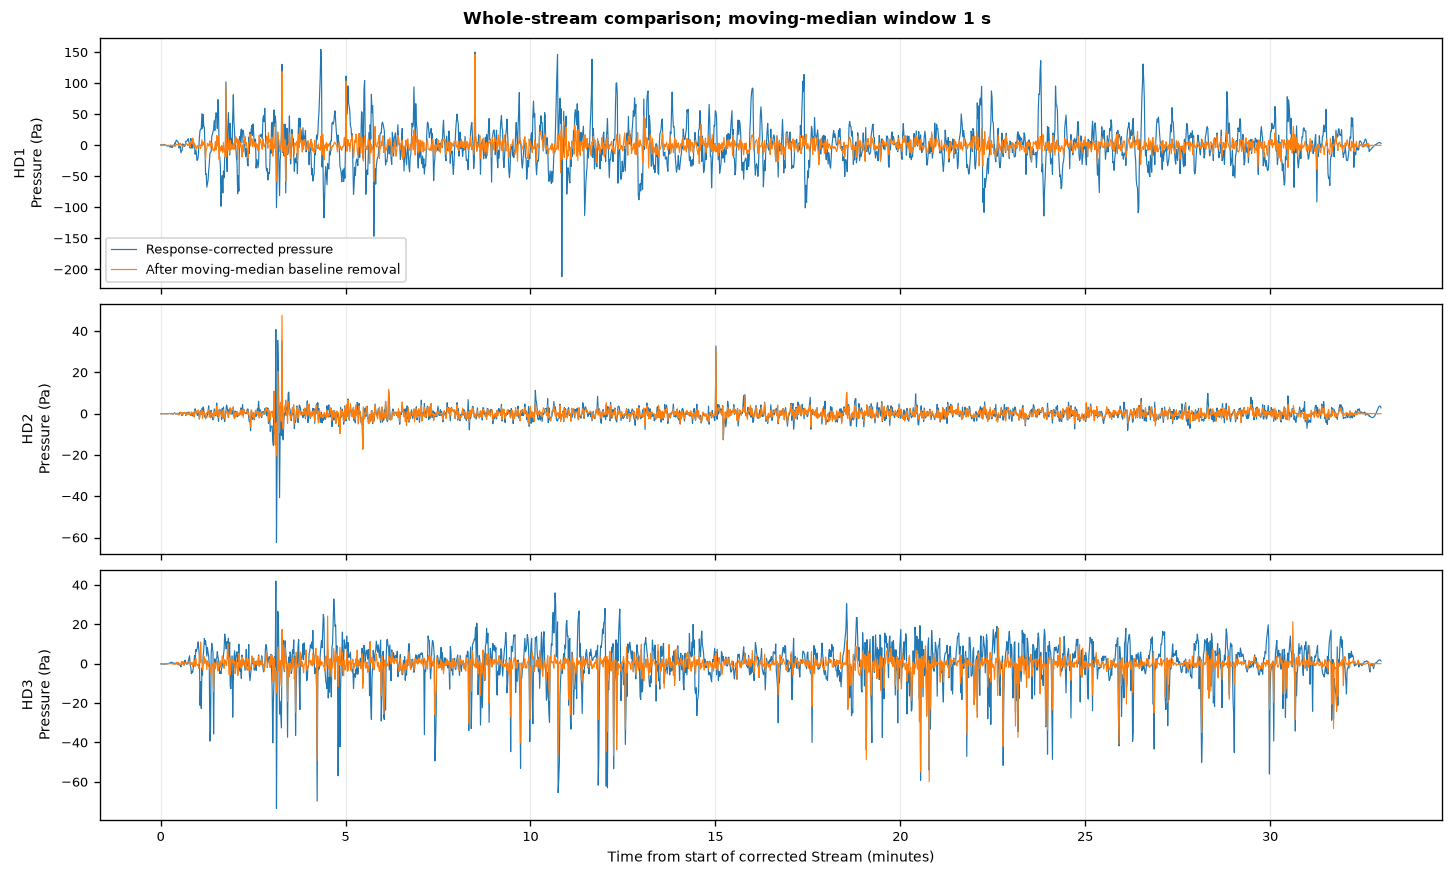

In [8]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12.0, 7.2),
    sharex=True,
    constrained_layout=True,
)

for axis, channel in zip(axes, INFRASOUND_CHANNELS):
    raw = st_corr.select(channel=channel)[0]
    corrected = st_corr_median_removed.select(
        channel=channel
    )[0]

    decimation = max(
        1,
        int(round(raw.stats.sampling_rate))
    )

    relative_minutes = (
        raw.times()[::decimation] / 60.0
    )

    axis.plot(
        relative_minutes,
        raw.data[::decimation],
        linewidth=0.7,
        label="Response-corrected pressure",
    )
    axis.plot(
        relative_minutes,
        corrected.data[::decimation],
        linewidth=0.7,
        label="After moving-median baseline removal",
    )
    axis.set_ylabel(f"{channel}\nPressure (Pa)")
    axis.grid(True, axis="x", alpha=0.25)

axes[0].legend()
axes[-1].set_xlabel(
    "Time from start of corrected Stream (minutes)"
)
fig.suptitle(
    f"Whole-stream comparison; moving-median window "
    f"{MOVING_MEDIAN_WINDOW_S:g} s",
    fontweight="bold",
)

comparison_path = (
    SUMMARY_PLOT_DIR
    / "whole_stream_raw_vs_baseline_removed.png"
)
fig.savefig(
    comparison_path,
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 9. Select the clearest events for detailed review

In [9]:
if not previously_selected_events.empty:
    candidate_numbers = set(
        previously_selected_events[
            "reconstructed_event_number"
        ].astype(int)
    )
    selection_pool = events.loc[
        events["reconstructed_event_number"].isin(
            candidate_numbers
        )
    ].copy()
else:
    selection_pool = events.loc[
        events["channel_count"] == 3
    ].copy()

selection_pool["rank_snr"] = (
    selection_pool["median_stack_snr"]
    .rank(ascending=False, method="min")
)
selection_pool["rank_amplitude"] = (
    selection_pool["peak_median_stack_pa"]
    .rank(ascending=False, method="min")
)
selection_pool["rank_pick_span"] = (
    selection_pool["corrected_pick_span_s"]
    .rank(ascending=True, method="min")
)

selection_pool["review_rank_score"] = (
    0.45 * selection_pool["rank_snr"]
    + 0.35 * selection_pool["rank_amplitude"]
    + 0.20 * selection_pool["rank_pick_span"]
)

selected_events = (
    selection_pool
    .sort_values(
        ["review_rank_score", "reconstructed_event_number"]
    )
    .tail(MAX_SELECTED_EVENTS)
    .reset_index(drop=True)
)

display(
    selected_events[
        [
            "reconstructed_event_number",
            "channels",
            "corrected_pick_span_s",
            "median_stack_snr",
            "peak_median_stack_pa",
            "review_rank_score",
        ]
    ]
)

selected_events.to_csv(
    DERIVED_OUTPUT_DIR
    / "selected_moving_median_review_events.csv",
    index=False,
)

,reconstructed_event_number,channels,corrected_pick_span_s,median_stack_snr,peak_median_stack_pa,review_rank_score
0,24,"HD1,HD2,HD3",0.003168,22.418860,151.998749,10.40
1,25,"HD1,HD2,HD3",0.005105,37.592104,89.616885,10.80
2,73,"HD1,HD2,HD3",0.005937,50.553224,40.264360,12.55
3,22,"HD1,HD2,HD3",0.004095,20.681255,168.129158,12.80
4,13,"HD1,HD2,HD3",0.003168,11.055173,702.186811,13.85
5,74,"HD1,HD2,HD3",0.007168,38.875696,32.983753,14.55
6,75,"HD1,HD2,HD3",0.001105,20.796180,32.285285,14.60
7,23,"HD1,HD2,HD3",0.005105,18.053947,145.452256,14.80
8,55,"HD1,HD2,HD3",0.008168,35.957049,41.196007,15.45
9,9,"HD1,HD2,HD3",0.003168,17.663340,85.109453,15.55


## 10. Differential travel-time helpers

In [10]:
def differential_delays_s(
    distances_m: Mapping[str, float],
    *,
    effective_speed_mps: float,
    reference_channel: str,
) -> dict[str, float]:
    reference_distance_m = distances_m[reference_channel]
    return {
        channel: (
            distance_m - reference_distance_m
        ) / effective_speed_mps
        for channel, distance_m in distances_m.items()
    }


DIFFERENTIAL_DELAYS_S = differential_delays_s(
    BCHH_INFRASOUND_DISTANCES_M,
    effective_speed_mps=WIND_CORRECTED_ACOUSTIC_SPEED_MPS,
    reference_channel=REFERENCE_CHANNEL,
)


def select_one_trace(
    stream: Stream,
    channel: str,
) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {len(matches)}"
        )
    return matches[0]


def shift_trace_to_reference(
    trace: Trace,
    delay_s: float,
) -> Trace:
    shifted = trace.copy()
    shifted.stats.starttime -= delay_s
    return shifted

## 11. Extract shifted raw and baseline-removed event arrays

In [11]:
def extract_shifted_event_arrays(
    event_epoch_s: float,
    *,
    stream: Stream,
) -> tuple[np.ndarray, dict[str, np.ndarray], float]:
    shifted_traces = {}

    for channel in INFRASOUND_CHANNELS:
        trace = select_one_trace(
            stream,
            channel,
        ).copy()
        trace = shift_trace_to_reference(
            trace,
            DIFFERENTIAL_DELAYS_S[channel],
        )
        trace.trim(
            UTCDateTime(event_epoch_s - EXTRACT_PRE_S),
            UTCDateTime(event_epoch_s + EXTRACT_POST_S),
            pad=False,
        )
        shifted_traces[channel] = trace

    sampling_rates = {
        float(trace.stats.sampling_rate)
        for trace in shifted_traces.values()
    }
    if len(sampling_rates) != 1:
        raise ValueError(
            "Infrasound traces have inconsistent sample rates"
        )
    sampling_rate_hz = sampling_rates.pop()

    common_start_s = max(
        float(trace.stats.starttime.timestamp)
        for trace in shifted_traces.values()
    )
    common_end_s = min(
        float(trace.stats.endtime.timestamp)
        for trace in shifted_traces.values()
    )

    sample_count = int(
        np.floor(
            (common_end_s - common_start_s)
            * sampling_rate_hz
        )
    ) + 1

    epoch_grid_s = (
        common_start_s
        + np.arange(sample_count) / sampling_rate_hz
    )
    relative_time_s = epoch_grid_s - event_epoch_s

    arrays = {}

    for channel, trace in shifted_traces.items():
        trace_times_s = (
            float(trace.stats.starttime.timestamp)
            + np.arange(trace.stats.npts)
            / sampling_rate_hz
        )
        arrays[channel] = np.interp(
            epoch_grid_s,
            trace_times_s,
            trace.data.astype(float),
        )

    return relative_time_s, arrays, sampling_rate_hz

## 12. Positive-compression/negative-rarefaction measurement

In [12]:
def robust_noise_scale(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - center))
    return 1.4826 * mad


def find_positive_negative_pair(
    values: np.ndarray,
    times_s: np.ndarray,
    *,
    search_window_s: tuple[float, float],
    minimum_lag_s: float,
    maximum_lag_s: float,
) -> dict:
    indices = np.flatnonzero(
        (times_s >= search_window_s[0])
        & (times_s <= search_window_s[1])
    )

    best = None

    for positive_index in indices:
        positive_value = values[positive_index]

        if (
            not np.isfinite(positive_value)
            or positive_value <= 0
        ):
            continue

        positive_time_s = times_s[positive_index]

        negative_candidates = indices[
            (
                times_s[indices]
                >= positive_time_s + minimum_lag_s
            )
            & (
                times_s[indices]
                <= positive_time_s + maximum_lag_s
            )
        ]

        if len(negative_candidates) == 0:
            continue

        negative_index = negative_candidates[
            np.nanargmin(values[negative_candidates])
        ]
        negative_value = values[negative_index]

        if (
            not np.isfinite(negative_value)
            or negative_value >= 0
        ):
            continue

        peak_to_peak = positive_value - negative_value

        if (
            best is None
            or peak_to_peak > best["peak_to_peak_pa"]
        ):
            best = {
                "valid_pair": True,
                "positive_index": int(positive_index),
                "negative_index": int(negative_index),
                "positive_time_s": float(positive_time_s),
                "negative_time_s": float(
                    times_s[negative_index]
                ),
                "positive_peak_pa": float(positive_value),
                "negative_peak_pa": float(negative_value),
                "peak_to_peak_pa": float(peak_to_peak),
                "positive_negative_lag_s": float(
                    times_s[negative_index]
                    - positive_time_s
                ),
            }

    if best is None:
        return {
            "valid_pair": False,
            "positive_index": np.nan,
            "negative_index": np.nan,
            "positive_time_s": np.nan,
            "negative_time_s": np.nan,
            "positive_peak_pa": np.nan,
            "negative_peak_pa": np.nan,
            "peak_to_peak_pa": np.nan,
            "positive_negative_lag_s": np.nan,
        }

    return best

## 13. Estimate event boundaries and impulse

In [13]:
def consecutive_true_run_start(
    condition: np.ndarray,
    run_length: int,
) -> int | None:
    if len(condition) < run_length:
        return None

    convolution = np.convolve(
        condition.astype(int),
        np.ones(run_length, dtype=int),
        mode="valid",
    )
    matches = np.flatnonzero(
        convolution == run_length
    )
    return int(matches[0]) if len(matches) else None


def event_boundaries_from_pair(
    corrected_values: np.ndarray,
    times_s: np.ndarray,
    pair: dict,
) -> dict:
    lag_s = pair["positive_negative_lag_s"]

    sinusoidal_start_s = (
        pair["positive_time_s"]
        - BOUNDARY_EXTENSION_FRACTION * lag_s
    )
    sinusoidal_end_s = (
        pair["negative_time_s"]
        + BOUNDARY_EXTENSION_FRACTION * lag_s
    )

    noise_mask = (
        (times_s >= NOISE_WINDOW_S[0])
        & (times_s <= NOISE_WINDOW_S[1])
    )
    noise_scale_pa = robust_noise_scale(
        corrected_values[noise_mask]
    )
    threshold_pa = (
        BOUNDARY_NOISE_MULTIPLIER * noise_scale_pa
    )

    event_start_s = sinusoidal_start_s
    event_end_s = sinusoidal_end_s
    start_method = "sinusoidal"
    end_method = "sinusoidal"

    if REFINE_BOUNDARIES_TO_NOISE:
        positive_index = int(pair["positive_index"])
        negative_index = int(pair["negative_index"])

        backward_indices = np.flatnonzero(
            (
                times_s
                >= sinusoidal_start_s
                - MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S
            )
            & (
                np.arange(len(times_s))
                < positive_index
            )
        )

        if len(backward_indices):
            reversed_indices = backward_indices[::-1]
            below = (
                np.abs(
                    corrected_values[reversed_indices]
                )
                <= threshold_pa
            )
            run_start = consecutive_true_run_start(
                below,
                BOUNDARY_CONSECUTIVE_SAMPLES,
            )
            if run_start is not None:
                chosen = reversed_indices[
                    run_start
                    + BOUNDARY_CONSECUTIVE_SAMPLES
                    - 1
                ]
                event_start_s = float(times_s[chosen])
                start_method = "noise_return"

        forward_indices = np.flatnonzero(
            (
                np.arange(len(times_s))
                > negative_index
            )
            & (
                times_s
                <= sinusoidal_end_s
                + MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S
            )
        )

        if len(forward_indices):
            below = (
                np.abs(
                    corrected_values[forward_indices]
                )
                <= threshold_pa
            )
            run_start = consecutive_true_run_start(
                below,
                BOUNDARY_CONSECUTIVE_SAMPLES,
            )
            if run_start is not None:
                chosen = forward_indices[run_start]
                event_end_s = float(times_s[chosen])
                end_method = "noise_return"

    return {
        "sinusoidal_start_s": sinusoidal_start_s,
        "sinusoidal_end_s": sinusoidal_end_s,
        "event_start_s": event_start_s,
        "event_end_s": event_end_s,
        "event_duration_s": event_end_s - event_start_s,
        "start_boundary_method": start_method,
        "end_boundary_method": end_method,
        "noise_scale_pa": noise_scale_pa,
        "boundary_threshold_pa": threshold_pa,
    }


def integrate_measurements(
    corrected_values: np.ndarray,
    times_s: np.ndarray,
    boundaries: dict,
) -> dict:
    mask = (
        (times_s >= boundaries["event_start_s"])
        & (times_s <= boundaries["event_end_s"])
    )

    if np.count_nonzero(mask) < 2:
        return {
            "pressure_impulse_pa_s": np.nan,
            "positive_impulse_pa_s": np.nan,
            "negative_impulse_pa_s": np.nan,
        }

    event_values = corrected_values[mask]
    event_times = times_s[mask]

    return {
        "pressure_impulse_pa_s": float(
            np.trapezoid(
                event_values,
                event_times,
            )
        ),
        "positive_impulse_pa_s": float(
            np.trapezoid(
                np.clip(event_values, 0, None),
                event_times,
            )
        ),
        "negative_impulse_pa_s": float(
            np.trapezoid(
                np.clip(event_values, None, 0),
                event_times,
            )
        ),
    }

## 14. Measure events relative to the moving-median baseline

In [14]:
def measure_moving_median_event(
    corrected_values: np.ndarray,
    times_s: np.ndarray,
) -> dict:
    pair = find_positive_negative_pair(
        corrected_values,
        times_s,
        search_window_s=SIGNAL_SEARCH_WINDOW_S,
        minimum_lag_s=(
            MINIMUM_POSITIVE_NEGATIVE_LAG_S
        ),
        maximum_lag_s=(
            MAXIMUM_POSITIVE_NEGATIVE_LAG_S
        ),
    )

    if not pair["valid_pair"]:
        return {
            "valid_measurement": False,
            "failure_reason": (
                "no positive-before-negative pair "
                "within allowed lag"
            ),
        }

    boundaries = event_boundaries_from_pair(
        corrected_values,
        times_s,
        pair,
    )
    impulses = integrate_measurements(
        corrected_values,
        times_s,
        boundaries,
    )

    return {
        "valid_measurement": True,
        "failure_reason": "",
        **pair,
        **boundaries,
        **impulses,
    }

## 15. Run measurements for selected events and channels

In [15]:
measurement_rows = []
measurement_cache = {}

for event in selected_events.itertuples(index=False):
    event_number = int(
        event.reconstructed_event_number
    )
    event_epoch_s = float(
        event.reduced_event_epoch_s
    )

    raw_times_s, raw_arrays, sampling_rate_hz = (
        extract_shifted_event_arrays(
            event_epoch_s,
            stream=st_corr,
        )
    )
    corrected_times_s, corrected_arrays, _ = (
        extract_shifted_event_arrays(
            event_epoch_s,
            stream=st_corr_median_removed,
        )
    )

    if not np.allclose(
        raw_times_s,
        corrected_times_s,
    ):
        raise ValueError(
            "Raw and corrected event grids differ"
        )

    raw_matrix = np.vstack([
        raw_arrays[channel]
        for channel in INFRASOUND_CHANNELS
    ])
    corrected_matrix = np.vstack([
        corrected_arrays[channel]
        for channel in INFRASOUND_CHANNELS
    ])

    raw_with_stack = {
        **raw_arrays,
        "median_stack": np.nanmedian(
            raw_matrix,
            axis=0,
        ),
    }
    corrected_with_stack = {
        **corrected_arrays,
        "median_stack": np.nanmedian(
            corrected_matrix,
            axis=0,
        ),
    }

    for waveform_type in [
        *INFRASOUND_CHANNELS,
        "median_stack",
    ]:
        result = measure_moving_median_event(
            corrected_with_stack[waveform_type],
            corrected_times_s,
        )

        measurement_rows.append({
            "reconstructed_event_number": event_number,
            "waveform_type": waveform_type,
            "moving_median_window_s": (
                MOVING_MEDIAN_WINDOW_S
            ),
            **result,
        })

        measurement_cache[
            (event_number, waveform_type)
        ] = {
            "times_s": corrected_times_s,
            "raw_values": raw_with_stack[
                waveform_type
            ],
            "corrected_values": corrected_with_stack[
                waveform_type
            ],
            **result,
        }

moving_median_measurements = pd.DataFrame(
    measurement_rows
)

moving_median_measurements.to_csv(
    DERIVED_OUTPUT_DIR
    / "moving_median_event_measurements.csv",
    index=False,
)

display(
    moving_median_measurements[
        "valid_measurement"
    ].value_counts()
)

valid_measurement
True     92
False     4
Name: count, dtype: int64

## Direct raw-versus-baseline-corrected event comparison

These figures are intentionally simpler than the measurement diagnostics.
Each channel and the median stack show the original response-corrected
waveform and the moving-median-corrected waveform on the same axes. This
makes it easy to judge whether baseline removal makes the arrival cleaner
without changing its timing or short-period shape.

In [16]:
def build_raw_corrected_comparison_figure(
    event_number: int,
):
    waveform_types = [
        *INFRASOUND_CHANNELS,
        "median_stack",
    ]

    fig, axes = plt.subplots(
        len(waveform_types),
        1,
        figsize=(10.5, 8.3),
        sharex=True,
        constrained_layout=True,
    )

    for axis, waveform_type in zip(
        axes,
        waveform_types,
    ):
        cached = measurement_cache[
            (event_number, waveform_type)
        ]
        times_s = cached["times_s"]
        raw = cached["raw_values"]
        corrected = cached["corrected_values"]

        axis.plot(
            times_s,
            raw,
            linewidth=0.95,
            alpha=0.80,
            label="Raw response-corrected pressure",
        )
        axis.plot(
            times_s,
            corrected,
            linewidth=1.05,
            label="Moving-median baseline removed",
        )
        axis.axhline(
            0.0,
            linewidth=0.55,
            alpha=0.55,
        )
        axis.axvline(
            0.0,
            linewidth=0.7,
            alpha=0.7,
        )
        axis.text(
            0.015,
            0.86,
            waveform_type,
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )

        if cached["valid_measurement"]:
            axis.axvspan(
                cached["event_start_s"],
                cached["event_end_s"],
                alpha=0.07,
            )
            axis.scatter(
                [cached["positive_time_s"]],
                [cached["positive_peak_pa"]],
                s=46,
                zorder=6,
            )
            axis.scatter(
                [cached["negative_time_s"]],
                [cached["negative_peak_pa"]],
                s=46,
                zorder=6,
            )

    axes[0].legend(
        loc="upper left",
        bbox_to_anchor=(0.0, 1.25),
        ncol=2,
        frameon=False,
    )
    axes[2].set_ylabel("Pressure (Pa)")
    axes[-1].set_xlabel(
        "Reduced time relative to event (s)"
    )

    event_row = selected_events.loc[
        selected_events[
            "reconstructed_event_number"
        ] == event_number
    ].iloc[0]

    fig.suptitle(
        f"Reconstructed event {event_number:03d}: "
        f"raw versus moving-median-corrected pressure\n"
        f"window {MOVING_MEDIAN_WINDOW_S:g} s; "
        f"initial median-stack SNR "
        f"{event_row['median_stack_snr']:.1f}",
        fontweight="bold",
    )

    return fig

### Generate raw-versus-corrected comparison PNGs

In [17]:
RAW_CORRECTED_COMPARISON_DIR = (
    OUTPUT_DIR / "raw_vs_corrected"
)
RAW_CORRECTED_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for index, event_number in enumerate(
    selected_events[
        "reconstructed_event_number"
    ].astype(int),
    start=1,
):
    figure = build_raw_corrected_comparison_figure(
        event_number
    )
    outfile = (
        RAW_CORRECTED_COMPARISON_DIR
        / f"event_{event_number:03d}_raw_vs_corrected.png"
    )
    figure.savefig(
        outfile,
        dpi=220,
        bbox_inches="tight",
    )
    plt.close(figure)

    if (
        index == 1
        or index % 5 == 0
        or index == len(selected_events)
    ):
        print(
            f"Generated {index} of "
            f"{len(selected_events)} comparison figures"
        )

Generated 1 of 24 comparison figures
Generated 5 of 24 comparison figures
Generated 10 of 24 comparison figures
Generated 15 of 24 comparison figures
Generated 20 of 24 comparison figures
Generated 24 of 24 comparison figures


### Preview one raw-versus-corrected comparison

In [18]:
'''preview_comparison = (
    build_raw_corrected_comparison_figure(
        20
    )
)
plt.show()'''

'preview_comparison = (\n    build_raw_corrected_comparison_figure(\n        20\n    )\n)\nplt.show()'

## 16. Detailed event diagnostic figures

In [19]:
def build_event_diagnostic_figure(
    event_number: int,
):
    waveform_types = [
        *INFRASOUND_CHANNELS,
        "median_stack",
    ]

    fig, axes = plt.subplots(
        len(waveform_types),
        2,
        figsize=(12.2, 9.2),
        sharex=True,
        constrained_layout=True,
    )

    for row_index, waveform_type in enumerate(
        waveform_types
    ):
        cached = measurement_cache[
            (event_number, waveform_type)
        ]
        times_s = cached["times_s"]
        raw = cached["raw_values"]
        corrected = cached["corrected_values"]
        baseline = raw - corrected

        raw_axis = axes[row_index, 0]
        corrected_axis = axes[row_index, 1]

        raw_axis.plot(
            times_s,
            raw,
            linewidth=0.9,
            label="Response-corrected pressure",
        )
        raw_axis.plot(
            times_s,
            baseline,
            linewidth=1.1,
            linestyle=":",
            label="Moving-median baseline",
        )
        raw_axis.axvline(
            0.0,
            linewidth=0.7,
            alpha=0.7,
        )
        raw_axis.text(
            0.015,
            0.86,
            waveform_type,
            transform=raw_axis.transAxes,
            fontweight="bold",
            va="top",
        )
        raw_axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )

        corrected_axis.plot(
            times_s,
            corrected,
            linewidth=1.0,
        )
        corrected_axis.axhline(
            0.0,
            linewidth=0.6,
            alpha=0.6,
        )
        corrected_axis.axvline(
            0.0,
            linewidth=0.7,
            alpha=0.7,
        )

        if cached["valid_measurement"]:
            corrected_axis.scatter(
                [cached["positive_time_s"]],
                [cached["positive_peak_pa"]],
                s=52,
                zorder=6,
                label="Positive peak",
            )
            corrected_axis.scatter(
                [cached["negative_time_s"]],
                [cached["negative_peak_pa"]],
                s=52,
                zorder=6,
                label="Negative peak",
            )
            corrected_axis.axvline(
                cached["sinusoidal_start_s"],
                linestyle=":",
                linewidth=0.8,
                label="Sinusoidal bounds",
            )
            corrected_axis.axvline(
                cached["sinusoidal_end_s"],
                linestyle=":",
                linewidth=0.8,
            )
            corrected_axis.axvline(
                cached["event_start_s"],
                linestyle="--",
                linewidth=0.9,
                label="Adopted bounds",
            )
            corrected_axis.axvline(
                cached["event_end_s"],
                linestyle="--",
                linewidth=0.9,
            )
            corrected_axis.axvspan(
                cached["event_start_s"],
                cached["event_end_s"],
                alpha=0.08,
            )

            summary_text = (
                f"+{cached['positive_peak_pa']:.2f} Pa at "
                f"{cached['positive_time_s']:.3f} s\n"
                f"{cached['negative_peak_pa']:.2f} Pa at "
                f"{cached['negative_time_s']:.3f} s\n"
                f"p-p {cached['peak_to_peak_pa']:.2f} Pa; "
                f"lag {cached['positive_negative_lag_s']:.3f} s\n"
                f"duration {cached['event_duration_s']:.3f} s; "
                f"impulse "
                f"{cached['pressure_impulse_pa_s']:.3g} Pa s"
            )
        else:
            summary_text = (
                f"Invalid: {cached['failure_reason']}"
            )

        corrected_axis.text(
            0.985,
            0.95,
            summary_text,
            transform=corrected_axis.transAxes,
            ha="right",
            va="top",
            fontsize=7.0,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": "0.7",
                "alpha": 0.92,
            },
        )
        corrected_axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )

    axes[0, 0].set_title(
        "Unfiltered pressure and moving-median baseline",
        fontweight="bold",
    )
    axes[0, 1].set_title(
        "Pressure after moving-median baseline removal",
        fontweight="bold",
    )

    for axis in axes[:, 0]:
        axis.set_ylabel("Pressure (Pa)")

    axes[-1, 0].set_xlabel(
        "Reduced time relative to event (s)"
    )
    axes[-1, 1].set_xlabel(
        "Reduced time relative to event (s)"
    )

    event_row = selected_events.loc[
        selected_events[
            "reconstructed_event_number"
        ] == event_number
    ].iloc[0]

    fig.suptitle(
        f"Reconstructed event {event_number:03d}: "
        f"moving-median baseline measurement\n"
        f"window {MOVING_MEDIAN_WINDOW_S:g} s; "
        f"initial median-stack SNR "
        f"{event_row['median_stack_snr']:.1f}; "
        f"minimum +/− lag "
        f"{MINIMUM_POSITIVE_NEGATIVE_LAG_S:.3f} s",
        fontweight="bold",
    )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=4,
            bbox_to_anchor=(0.5, -0.012),
            frameon=False,
        )

    return fig

## 17. Generate detailed PNGs

In [20]:
if WRITE_EVENT_DIAGNOSTIC_PNGS:
    for index, event_number in enumerate(
        selected_events[
            "reconstructed_event_number"
        ].astype(int),
        start=1,
    ):
        figure = build_event_diagnostic_figure(
            event_number
        )
        outfile = (
            EVENT_PLOT_DIR
            / f"event_{event_number:03d}_moving_median.png"
        )
        figure.savefig(
            outfile,
            dpi=220,
            bbox_inches="tight",
        )
        plt.close(figure)

        if (
            index == 1
            or index % 5 == 0
            or index == len(selected_events)
        ):
            print(
                f"Generated {index} of "
                f"{len(selected_events)} figures"
            )

Generated 1 of 24 figures
Generated 5 of 24 figures
Generated 10 of 24 figures
Generated 15 of 24 figures
Generated 20 of 24 figures
Generated 24 of 24 figures


## 18. Preview one event

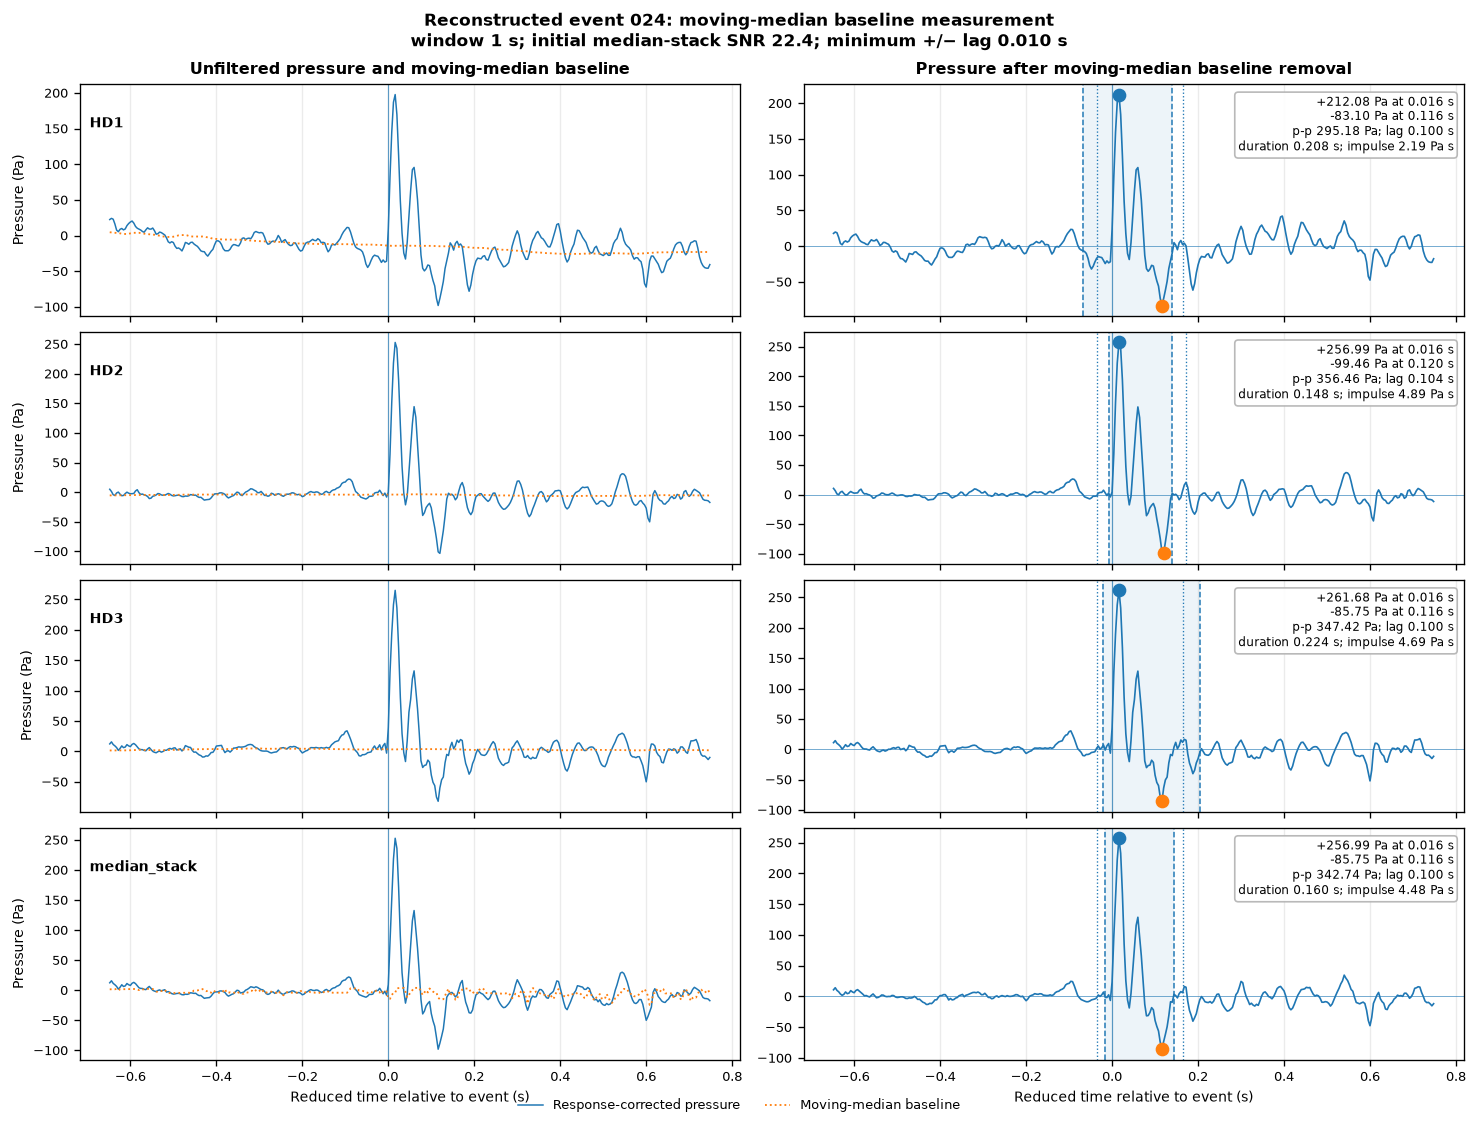

In [21]:
PREVIEW_EVENT_NUMBER = int(
    selected_events.iloc[0][
        "reconstructed_event_number"
    ]
)

preview_figure = build_event_diagnostic_figure(
    PREVIEW_EVENT_NUMBER
)
plt.show()

## 19. Cross-channel consistency and lag checks

In [22]:
valid_channel_measurements = (
    moving_median_measurements.loc[
        moving_median_measurements[
            "waveform_type"
        ].isin(INFRASOUND_CHANNELS)
        & moving_median_measurements[
            "valid_measurement"
        ]
    ]
    .copy()
)

event_consistency = (
    valid_channel_measurements
    .groupby("reconstructed_event_number")
    .agg(
        channel_count=("waveform_type", "nunique"),
        median_positive_peak_pa=(
            "positive_peak_pa",
            "median",
        ),
        median_negative_peak_pa=(
            "negative_peak_pa",
            "median",
        ),
        median_peak_to_peak_pa=(
            "peak_to_peak_pa",
            "median",
        ),
        positive_time_range_s=(
            "positive_time_s",
            lambda x: x.max() - x.min(),
        ),
        negative_time_range_s=(
            "negative_time_s",
            lambda x: x.max() - x.min(),
        ),
        median_lag_s=(
            "positive_negative_lag_s",
            "median",
        ),
        lag_range_s=(
            "positive_negative_lag_s",
            lambda x: x.max() - x.min(),
        ),
        median_duration_s=(
            "event_duration_s",
            "median",
        ),
    )
    .reset_index()
)

display(event_consistency)

event_consistency.to_csv(
    DERIVED_OUTPUT_DIR
    / "moving_median_cross_channel_consistency.csv",
    index=False,
)

,reconstructed_event_number,channel_count,median_positive_peak_pa,median_negative_peak_pa,median_peak_to_peak_pa,positive_time_range_s,negative_time_range_s,median_lag_s,lag_range_s,median_duration_s
0,3,3,37.584274,-8.992576,46.586061,0.004,0.076,0.032,0.072,0.052
1,6,3,33.374021,-20.767569,54.141590,0.008,0.004,0.156,0.012,0.220
2,9,3,104.862387,-77.313856,171.455198,0.000,0.004,0.028,0.004,0.072
3,14,3,317.957678,-91.206027,410.100594,0.000,0.000,0.144,0.000,0.336
4,15,3,317.957678,-129.047375,447.005053,0.000,0.016,0.152,0.016,0.180
5,22,3,272.666362,-104.666447,383.398465,0.004,0.004,0.044,0.000,0.120
6,23,3,290.843057,-113.159056,404.002114,0.004,0.004,0.112,0.000,0.176
7,24,3,256.992980,-85.747103,347.422419,0.000,0.004,0.100,0.004,0.208
8,25,3,96.036581,-99.275996,193.571667,0.004,0.004,0.036,0.000,0.102
9,26,3,35.173717,-11.863265,46.983734,0.004,0.056,0.136,0.060,0.164


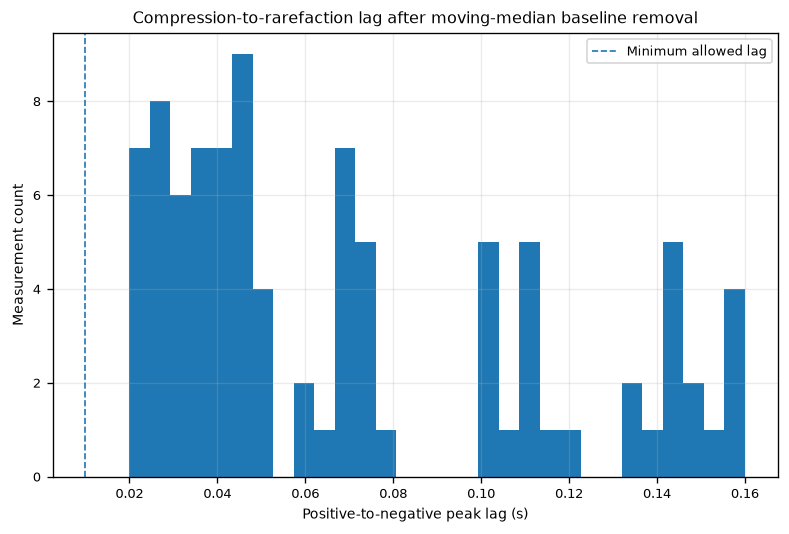

In [23]:
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.hist(
    moving_median_measurements.loc[
        moving_median_measurements[
            "valid_measurement"
        ],
        "positive_negative_lag_s",
    ],
    bins=30,
)
ax.axvline(
    MINIMUM_POSITIVE_NEGATIVE_LAG_S,
    linestyle="--",
    linewidth=1.0,
    label="Minimum allowed lag",
)
ax.set_xlabel(
    "Positive-to-negative peak lag (s)"
)
ax.set_ylabel("Measurement count")
ax.set_title(
    "Compression-to-rarefaction lag after "
    "moving-median baseline removal"
)
ax.grid(True, alpha=0.25)
ax.legend()

lag_figure = (
    SUMMARY_PLOT_DIR
    / "positive_negative_lag_histogram.png"
)
fig.savefig(
    lag_figure,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Moving-median window-length sensitivity

This experiment recomputes the moving-median baseline for selected events
using 0.25, 0.5, 1.0, and 2.0 s windows. It compares how much the measured
peak-to-peak pressure and baseline vary with window length.

The preferred window should lie on a stability plateau. A window is too
short when it follows and partially removes the pulse; it is unnecessarily
long when it fails to track genuine baseline variation.

In [24]:
window_sensitivity_rows = []
window_sensitivity_cache = {}

for event in selected_events.itertuples(index=False):
    event_number = int(
        event.reconstructed_event_number
    )
    event_epoch_s = float(
        event.reduced_event_epoch_s
    )

    times_s, raw_arrays, sampling_rate_hz = (
        extract_shifted_event_arrays(
            event_epoch_s,
            stream=st_corr,
        )
    )

    raw_matrix = np.vstack([
        raw_arrays[channel]
        for channel in INFRASOUND_CHANNELS
    ])
    raw_with_stack = {
        **raw_arrays,
        "median_stack": np.nanmedian(
            raw_matrix,
            axis=0,
        ),
    }

    for waveform_type, raw_values in raw_with_stack.items():
        for window_s in MOVING_MEDIAN_TEST_WINDOWS_S:
            baseline = moving_median_baseline(
                raw_values,
                sampling_rate_hz=sampling_rate_hz,
                window_s=window_s,
            )
            corrected = raw_values - baseline

            result = measure_moving_median_event(
                corrected,
                times_s,
            )

            window_sensitivity_rows.append({
                "reconstructed_event_number": event_number,
                "waveform_type": waveform_type,
                "moving_median_window_s": window_s,
                **result,
            })

            window_sensitivity_cache[
                (event_number, waveform_type, window_s)
            ] = {
                "times_s": times_s,
                "raw_values": raw_values,
                "baseline": baseline,
                "corrected_values": corrected,
                **result,
            }

window_sensitivity = pd.DataFrame(
    window_sensitivity_rows
)

window_sensitivity.to_csv(
    DERIVED_OUTPUT_DIR
    / "moving_median_window_sensitivity.csv",
    index=False,
)

display(
    window_sensitivity.loc[
        window_sensitivity["waveform_type"]
        == "median_stack"
    ]
    .groupby("moving_median_window_s")
    .agg(
        valid_fraction=("valid_measurement", "mean"),
        median_positive_peak_pa=("positive_peak_pa", "median"),
        median_negative_peak_pa=("negative_peak_pa", "median"),
        median_peak_to_peak_pa=("peak_to_peak_pa", "median"),
        median_lag_s=("positive_negative_lag_s", "median"),
        median_duration_s=("event_duration_s", "median"),
    )
)

,valid_fraction,median_positive_peak_pa,median_negative_peak_pa,median_peak_to_peak_pa,median_lag_s,median_duration_s
moving_median_window_s,,,,,,
0.125,1.000000,50.591432,-18.774794,65.354505,0.044,0.110
0.250,1.000000,51.091659,-17.918494,65.580570,0.064,0.136
0.500,1.000000,50.926160,-15.671600,65.631470,0.064,0.143
1.000,0.958333,47.958141,-18.074753,65.582468,0.060,0.136
2.000,0.958333,47.727345,-18.074753,65.630103,0.060,0.136


In [25]:
def build_window_sensitivity_figure(
    event_number: int,
    waveform_type: str = "median_stack",
):
    windows = list(MOVING_MEDIAN_TEST_WINDOWS_S)

    fig, axes = plt.subplots(
        len(windows),
        2,
        figsize=(11.5, 2.5 * len(windows)),
        sharex=True,
        constrained_layout=True,
    )

    for row_index, window_s in enumerate(windows):
        cached = window_sensitivity_cache[
            (event_number, waveform_type, window_s)
        ]

        raw_axis = axes[row_index, 0]
        corrected_axis = axes[row_index, 1]

        raw_axis.plot(
            cached["times_s"],
            cached["raw_values"],
            linewidth=0.9,
            label="Raw",
        )
        raw_axis.plot(
            cached["times_s"],
            cached["baseline"],
            linestyle=":",
            linewidth=1.1,
            label="Moving median",
        )
        raw_axis.text(
            0.015,
            0.84,
            f"{window_s:g} s window",
            transform=raw_axis.transAxes,
            fontweight="bold",
            va="top",
        )
        raw_axis.grid(True, axis="x", alpha=0.25)

        corrected_axis.plot(
            cached["times_s"],
            cached["corrected_values"],
            linewidth=1.0,
        )
        corrected_axis.axhline(
            0.0,
            linewidth=0.55,
            alpha=0.55,
        )
        corrected_axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )

        if cached["valid_measurement"]:
            corrected_axis.scatter(
                [cached["positive_time_s"]],
                [cached["positive_peak_pa"]],
                s=44,
                zorder=6,
            )
            corrected_axis.scatter(
                [cached["negative_time_s"]],
                [cached["negative_peak_pa"]],
                s=44,
                zorder=6,
            )
            corrected_axis.set_title(
                f"p-p {cached['peak_to_peak_pa']:.2f} Pa; "
                f"lag {cached['positive_negative_lag_s']:.3f} s"
            )

    axes[0, 0].set_title(
        "Raw waveform and candidate baseline",
        fontweight="bold",
    )
    axes[-1, 0].set_xlabel(
        "Reduced time relative to event (s)"
    )
    axes[-1, 1].set_xlabel(
        "Reduced time relative to event (s)"
    )

    fig.suptitle(
        f"Event {event_number:03d}: "
        f"moving-median window sensitivity ({waveform_type})",
        fontweight="bold",
    )

    return fig

In [26]:
WINDOW_SENSITIVITY_DIR = (
    OUTPUT_DIR / "window_sensitivity"
)
WINDOW_SENSITIVITY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for event_number in selected_events[
    "reconstructed_event_number"
].astype(int):
    figure = build_window_sensitivity_figure(
        event_number,
        waveform_type="median_stack",
    )
    outfile = (
        WINDOW_SENSITIVITY_DIR
        / f"event_{event_number:03d}_window_sensitivity.png"
    )
    figure.savefig(
        outfile,
        dpi=220,
        bbox_inches="tight",
    )
    plt.close(figure)

print(
    f"Wrote sensitivity figures to "
    f"{WINDOW_SENSITIVITY_DIR}"
)

Wrote sensitivity figures to /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/moving_median_baseline/window_sensitivity


## 20. Interpretation and quality control

The moving median is now the adopted baseline model, not merely an initializer.
Before extending the measurements to the entire catalogue, visually inspect:

- whether the moving median passes through the slowly varying background rather
  than through the impulsive signal;
- whether a 1.0 s window is sufficiently long for the largest and broadest
  arrivals;
- whether the positive peak is followed by the physically associated negative
  peak rather than a later neighboring event;
- whether the 0.01 s minimum lag rejects high-frequency sample-to-sample
  fluctuations without excluding convincing short airwaves;
- whether noise-refined event boundaries are more plausible than the simple
  sinusoidal bounds;
- whether nearby events contaminate the inferred event interval.

A 1 Hz high-pass may later be used only as a **guide** for ambiguous weak events.
It is not applied to the pressure values measured here.